##<p><strong>Paso: Librerias y cargar datos</strong></br>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn import metrics
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [63]:
archivo=('Base_Pruebas_INTNEG (FUGA).xlsx')
df=pd.read_excel(archivo)

In [64]:
archivo2=('Oficina.xlsx')
df0=pd.read_excel(archivo2)

In [175]:
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191 entries, 0 to 190
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   SK_OFICINA                    191 non-null    int64  
 1   PART. CLIENTES AMBITO URBANO  191 non-null    float64
 2   No_EDPs                       191 non-null    int64  
 3   PG SIN BANAGRARIO             191 non-null    float64
 4   TASA COMPETIDOR               191 non-null    float64
 5   PARTICIPACION COMPETIDOR      191 non-null    float64
 6   RIESGO                        191 non-null    object 
dtypes: float64(4), int64(2), object(1)
memory usage: 10.6+ KB


In [65]:
key='SK_OFICINA'
df = pd.merge(df, df0, on=key, how='left')

In [66]:
# Creamos la lista de columnas
columnas_clave = ['SK_OFICINA','OFICINA','ZONA','TERRITORIAL','CUENTA_CLIENTE','SK_CAMPAÑA','TASA','MORA',
'RANGO_MORA','CALIFICACION','GARANTIA','SALDO_CAPITAL','MONTO_DESEMBOLSADO','NUMERO_CUOTAS','NUMERO_CUOTAS_PAGADAS',
'CUOTAS_RESTANTES','FECHA_DESEMBOLSO','RT_SALDO_DESEMBOLSO','GRUPO_RIESGO','GENERO','AMBITO','IND_AGRO','COD_MUNICIPIO_CLIENTE',
'MUNICIPIO_CLIENTE','RANGO_EDAD','NOTA_CLIENTE','CLASIFICACION','ENTIDADES_ALERTA','CLIENTE_DIGITAL','MARCA_CLIENTE','MARCA_FUGA']

# Eliminamos duplicados manteniendo la primera aparición
df = df.drop_duplicates(subset=columnas_clave)

In [67]:
(len(df))

126369

In [68]:
# Contar rango erróneo
anomalos = df[df['TASA'] > 6600]
print(f"Son {len(anomalos)} registros con tasas sospechosas.")

Son 472 registros con tasas sospechosas.


In [69]:
# limitar valor final debe ser 5.53 
df.loc[df['TASA'] > 66, 'TASA'] = df.loc[df['TASA'] > 66, 'TASA'] / 10000000 

In [70]:
df['TASA'].describe()

count    126369.000000
mean         45.759732
std           8.876596
min           0.000000
25%          43.200000
50%          47.200000
75%          51.110000
max          65.810000
Name: TASA, dtype: float64

In [71]:
#Identificar y corregir los valores fuera del rango lógico (> 65.81)
#imputacion con la mediana (47.2 (50%))
df['TASA'] = np.where(df['TASA'] > 65.81, 47.20, df['TASA'])

In [72]:
df['TASA'].describe()

count    126369.000000
mean         45.759732
std           8.876596
min           0.000000
25%          43.200000
50%          47.200000
75%          51.110000
max          65.810000
Name: TASA, dtype: float64

In [122]:
df['MORA'].describe()

count    126369.000000
mean          7.556766
std          34.241204
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        1845.000000
Name: MORA, dtype: float64

In [123]:
df.MORA

0           0
1           0
2           0
3           0
4          25
         ... 
126364    148
126365      0
126366      0
126367     79
126368      0
Name: MORA, Length: 126369, dtype: int64

In [97]:
# df.to_excel('datos_Tasa.xlsx', index=False)

In [92]:
# # TEST
# valor_bytes = 55366869

# # Dividir por la potencia de 10 
# resultado = valor_bytes / (10**12)

# print(f"{resultado} TB")

In [73]:
# Suma los True,a
print(df.isna().sum())
# Para ver el total global de nulos 
print(df.isna().sum().sum())

SK_OFICINA                           0
OFICINA                              0
ZONA                                 0
TERRITORIAL                          0
CUENTA_CLIENTE                       0
SK_CAMPAÑA                           0
TASA                                 0
MORA                                 0
RANGO_MORA                           0
CALIFICACION                         0
GARANTIA                             0
SALDO_CAPITAL                        0
MONTO_DESEMBOLSADO                   0
NUMERO_CUOTAS                        0
NUMERO_CUOTAS_PAGADAS                0
CUOTAS_RESTANTES                     0
FECHA_DESEMBOLSO                     0
RT_SALDO_DESEMBOLSO                  0
GRUPO_RIESGO                        98
GENERO                               0
AMBITO                               0
IND_AGRO                             0
COD_MUNICIPIO_CLIENTE                0
MUNICIPIO_CLIENTE                    0
RANGO_EDAD                           0
NOTA_CLIENTE             

##<p><strong>Paso: EDA (exploracion de los datos)</strong></br>

In [74]:
df.RIESGO

0           NaN
1          alto
2         medio
3         medio
4         medio
          ...  
126364     alto
126365     alto
126366    medio
126367     bajo
126368      NaN
Name: RIESGO, Length: 126369, dtype: object

In [8]:
# #  imputación agrupada (Moda)

# #  moda 0
# moda_categoria = df['RIESGO'].mode()[0]

# # Rellenamos
# df['RIESGO'] = df['RIESGO'].fillna(moda_categoria)

In [75]:
df = df.drop('CUENTA_CLIENTE', axis=1)
df.describe()

,SK_OFICINA,SK_CAMPAÑA,TASA,MORA,GARANTIA,SALDO_CAPITAL,MONTO_DESEMBOLSADO,NUMERO_CUOTAS,NUMERO_CUOTAS_PAGADAS,CUOTAS_RESTANTES,...,COD_MUNICIPIO_CLIENTE,NOTA_CLIENTE,ENTIDADES_ALERTA,CLIENTE_DIGITAL,MARCA_FUGA,PART. CLIENTES AMBITO URBANO,No_EDPs,PG SIN BANAGRARIO,TASA COMPETIDOR,PARTICIPACION COMPETIDOR
count,126369.000000,126369.000000,126369.000000,126369.000000,126369.000000,1.263690e+05,1.263690e+05,126369.000000,126369.000000,126369.000000,...,126369.000000,126369.000000,4475.000000,126369.000000,126369.000000,109541.000000,109541.000000,109541.000000,109541.000000,109541.000000
mean,329.961185,15.539824,45.759732,7.556766,0.349231,5.233120e+06,7.299837e+06,25.941386,10.738781,15.205224,...,36614.233190,4.000641,1.196201,0.449082,0.184808,0.561786,5.020842,0.242722,0.426443,0.429661
std,103.830472,50.880975,8.876596,34.241204,0.476729,7.912977e+06,9.502779e+06,12.685608,9.215209,11.043194,...,27504.782899,1.529752,0.507815,0.497403,0.388143,0.267380,2.272124,0.229202,0.072921,0.159475
min,202.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,1.391693e+04,0.000000,0.000000,0.000000,...,-8888.000000,0.000000,1.000000,0.000000,0.000000,0.045987,2.000000,0.006727,0.276885,0.153011
25%,261.000000,0.000000,43.200000,0.000000,0.000000,1.456958e+06,2.734480e+06,18.000000,4.000000,6.000000,...,13001.000000,3.000000,1.000000,0.000000,0.000000,0.345921,4.000000,0.075353,0.409720,0.335571
50%,312.000000,0.000000,47.200000,0.000000,0.000000,3.145746e+06,5.058560e+06,24.000000,9.000000,13.000000,...,25086.000000,5.000000,1.000000,0.000000,0.000000,0.514433,4.000000,0.168578,0.427377,0.400650
75%,362.000000,0.000000,51.110000,0.000000,1.000000,5.984351e+06,8.134612e+06,36.000000,15.000000,23.000000,...,66440.000000,5.000000,1.000000,1.000000,0.000000,0.783951,6.000000,0.337800,0.496813,0.501979
max,643.000000,266.000000,65.810000,1845.000000,1.000000,1.560000e+08,1.560000e+08,145.000000,111.000000,126.000000,...,99524.000000,5.000000,6.000000,1.000000,1.000000,1.000000,16.000000,1.000000,0.573926,1.000000


In [76]:
df.dtypes

SK_OFICINA                        int64
OFICINA                          object
ZONA                             object
TERRITORIAL                      object
SK_CAMPAÑA                        int64
TASA                            float64
MORA                              int64
RANGO_MORA                       object
CALIFICACION                     object
GARANTIA                          int64
SALDO_CAPITAL                   float64
MONTO_DESEMBOLSADO              float64
NUMERO_CUOTAS                     int64
NUMERO_CUOTAS_PAGADAS             int64
CUOTAS_RESTANTES                  int64
FECHA_DESEMBOLSO                  int64
RT_SALDO_DESEMBOLSO             float64
GRUPO_RIESGO                     object
GENERO                           object
AMBITO                           object
IND_AGRO                          int64
COD_MUNICIPIO_CLIENTE             int64
MUNICIPIO_CLIENTE                object
RANGO_EDAD                       object
NOTA_CLIENTE                      int64


In [77]:
df.groupby('MARCA_FUGA').size()

MARCA_FUGA
0    103015
1     23354
dtype: int64

In [78]:
df.groupby('RIESGO').size()

RIESGO
alto     28177
bajo     38512
medio    42852
dtype: int64

In [79]:
df['FECHA_DESEMBOLSO'] = pd.to_datetime(df['FECHA_DESEMBOLSO'], unit='D', origin='1899-12-30')

In [80]:
df['CALIFICACION'] = df['CALIFICACION'].str.strip()
df['CALIFICACION'] = df['CALIFICACION'].astype('string')

df['MARCA_CLIENTE'] = df['MARCA_CLIENTE'].str.strip()
df['MARCA_CLIENTE'] = df['MARCA_CLIENTE'].astype('string')

# df['RIESGO'] = df['RIESGO'].astype(str)
df['RIESGO'] = df['RIESGO'].astype("string")

df['GENERO'] = df['GENERO'].str.strip()
df['GENERO'] = df['GENERO'].astype('string')

In [81]:
df['CALIFICACION'].dtypes
# df['MARCA_CLIENTE'].dtypes
# df.dtypes

string[python]

In [82]:
df['GENERO'].dtypes

string[python]

In [83]:
df['RIESGO'].dtypes

string[python]

In [11]:
# NAN_EN_MARCA_FUGA = df[df['MARCA_FUGA'].isnull()]
# NAN_EN_MARCA_FUGA = df[df['MARCA_FUGA'].isna()]
# pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [15]:
# df.groupby('SALDO_CAPITAL').sum()

In [21]:
# resumen = df.groupby('OFICINA')['SALDO_CAPITAL'].sum().reset_index()
# resumen

# resumen = df.groupby('OFICINA')['CUOTAS_RESTANTES'].sum().reset_index()
# resumen
# resumen = df.groupby('OFICINA')['MONTO_DESEMBOLSADO'].sum().reset_index()
# resumen

# resumen = df.groupby('OFICINA')['MORA'].sum().reset_index()
# resumen


In [84]:
df2 = df.select_dtypes(include=['int64', 'float64','string'])

In [85]:
df2.describe(include='all')

,SK_OFICINA,SK_CAMPAÑA,TASA,MORA,CALIFICACION,GARANTIA,SALDO_CAPITAL,MONTO_DESEMBOLSADO,NUMERO_CUOTAS,NUMERO_CUOTAS_PAGADAS,...,ENTIDADES_ALERTA,CLIENTE_DIGITAL,MARCA_CLIENTE,MARCA_FUGA,PART. CLIENTES AMBITO URBANO,No_EDPs,PG SIN BANAGRARIO,TASA COMPETIDOR,PARTICIPACION COMPETIDOR,RIESGO
count,126369.000000,126369.000000,126369.000000,126369.000000,126369,126369.000000,1.263690e+05,1.263690e+05,126369.000000,126369.000000,...,4475.000000,126369.000000,126369,126369.000000,109541.000000,109541.000000,109541.000000,109541.000000,109541.000000,109541
unique,NaN,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,A,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1. PERFIL_BUEN_CLIENTE,NaN,NaN,NaN,NaN,NaN,NaN,medio
freq,NaN,NaN,NaN,NaN,111429,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,69796,NaN,NaN,NaN,NaN,NaN,NaN,42852
mean,329.961185,15.539824,45.759732,7.556766,NaN,0.349231,5.233120e+06,7.299837e+06,25.941386,10.738781,...,1.196201,0.449082,NaN,0.184808,0.561786,5.020842,0.242722,0.426443,0.429661,NaN
std,103.830472,50.880975,8.876596,34.241204,NaN,0.476729,7.912977e+06,9.502779e+06,12.685608,9.215209,...,0.507815,0.497403,NaN,0.388143,0.267380,2.272124,0.229202,0.072921,0.159475,NaN
min,202.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000e+00,1.391693e+04,0.000000,0.000000,...,1.000000,0.000000,NaN,0.000000,0.045987,2.000000,0.006727,0.276885,0.153011,NaN
25%,261.000000,0.000000,43.200000,0.000000,NaN,0.000000,1.456958e+06,2.734480e+06,18.000000,4.000000,...,1.000000,0.000000,NaN,0.000000,0.345921,4.000000,0.075353,0.409720,0.335571,NaN
50%,312.000000,0.000000,47.200000,0.000000,NaN,0.000000,3.145746e+06,5.058560e+06,24.000000,9.000000,...,1.000000,0.000000,NaN,0.000000,0.514433,4.000000,0.168578,0.427377,0.400650,NaN
75%,362.000000,0.000000,51.110000,0.000000,NaN,1.000000,5.984351e+06,8.134612e+06,36.000000,15.000000,...,1.000000,1.000000,NaN,0.000000,0.783951,6.000000,0.337800,0.496813,0.501979,NaN


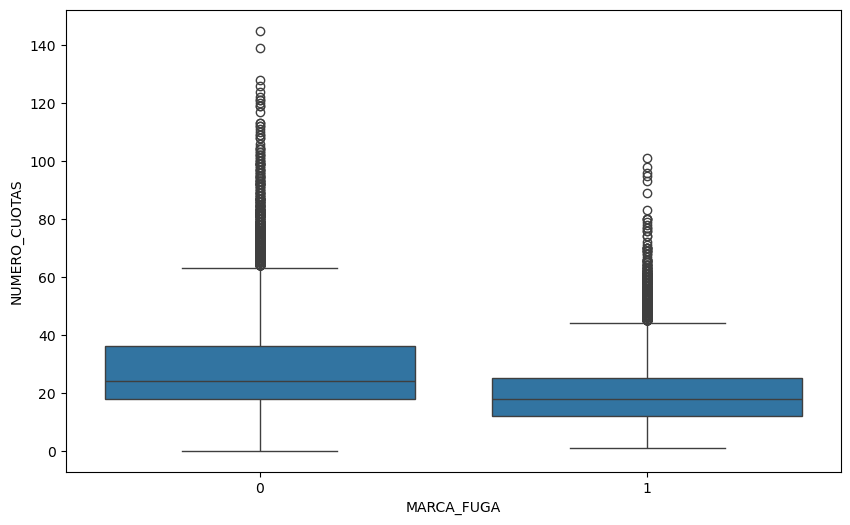

In [86]:
plt.figure(figsize=(10, 6))
# sns.boxplot(data=df, x='MARCA_FUGA', y='CUOTAS_RESTANTES')
# sns.boxplot(data=df, x='MARCA_FUGA', y='NUMERO_CUOTAS_PAGADAS')
sns.boxplot(data=df, x='MARCA_FUGA', y='NUMERO_CUOTAS')
# --- AQUÍ ESTÁ EL TRUCO ---
plt.ticklabel_format(style='plain', axis='y') 
# Si el saldo está en el eje X, cambia axis='y' por axis='x'
plt.show()

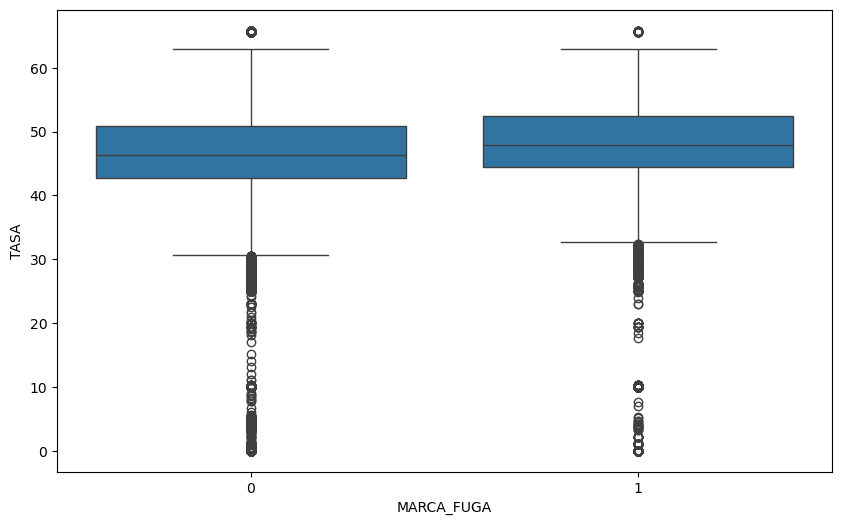

In [87]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='MARCA_FUGA', y='TASA')
# --- AQUÍ ESTÁ EL TRUCO ---
plt.ticklabel_format(style='plain', axis='y') 
# Si el saldo está en el eje X, cambia axis='y' por axis='x'
plt.show()

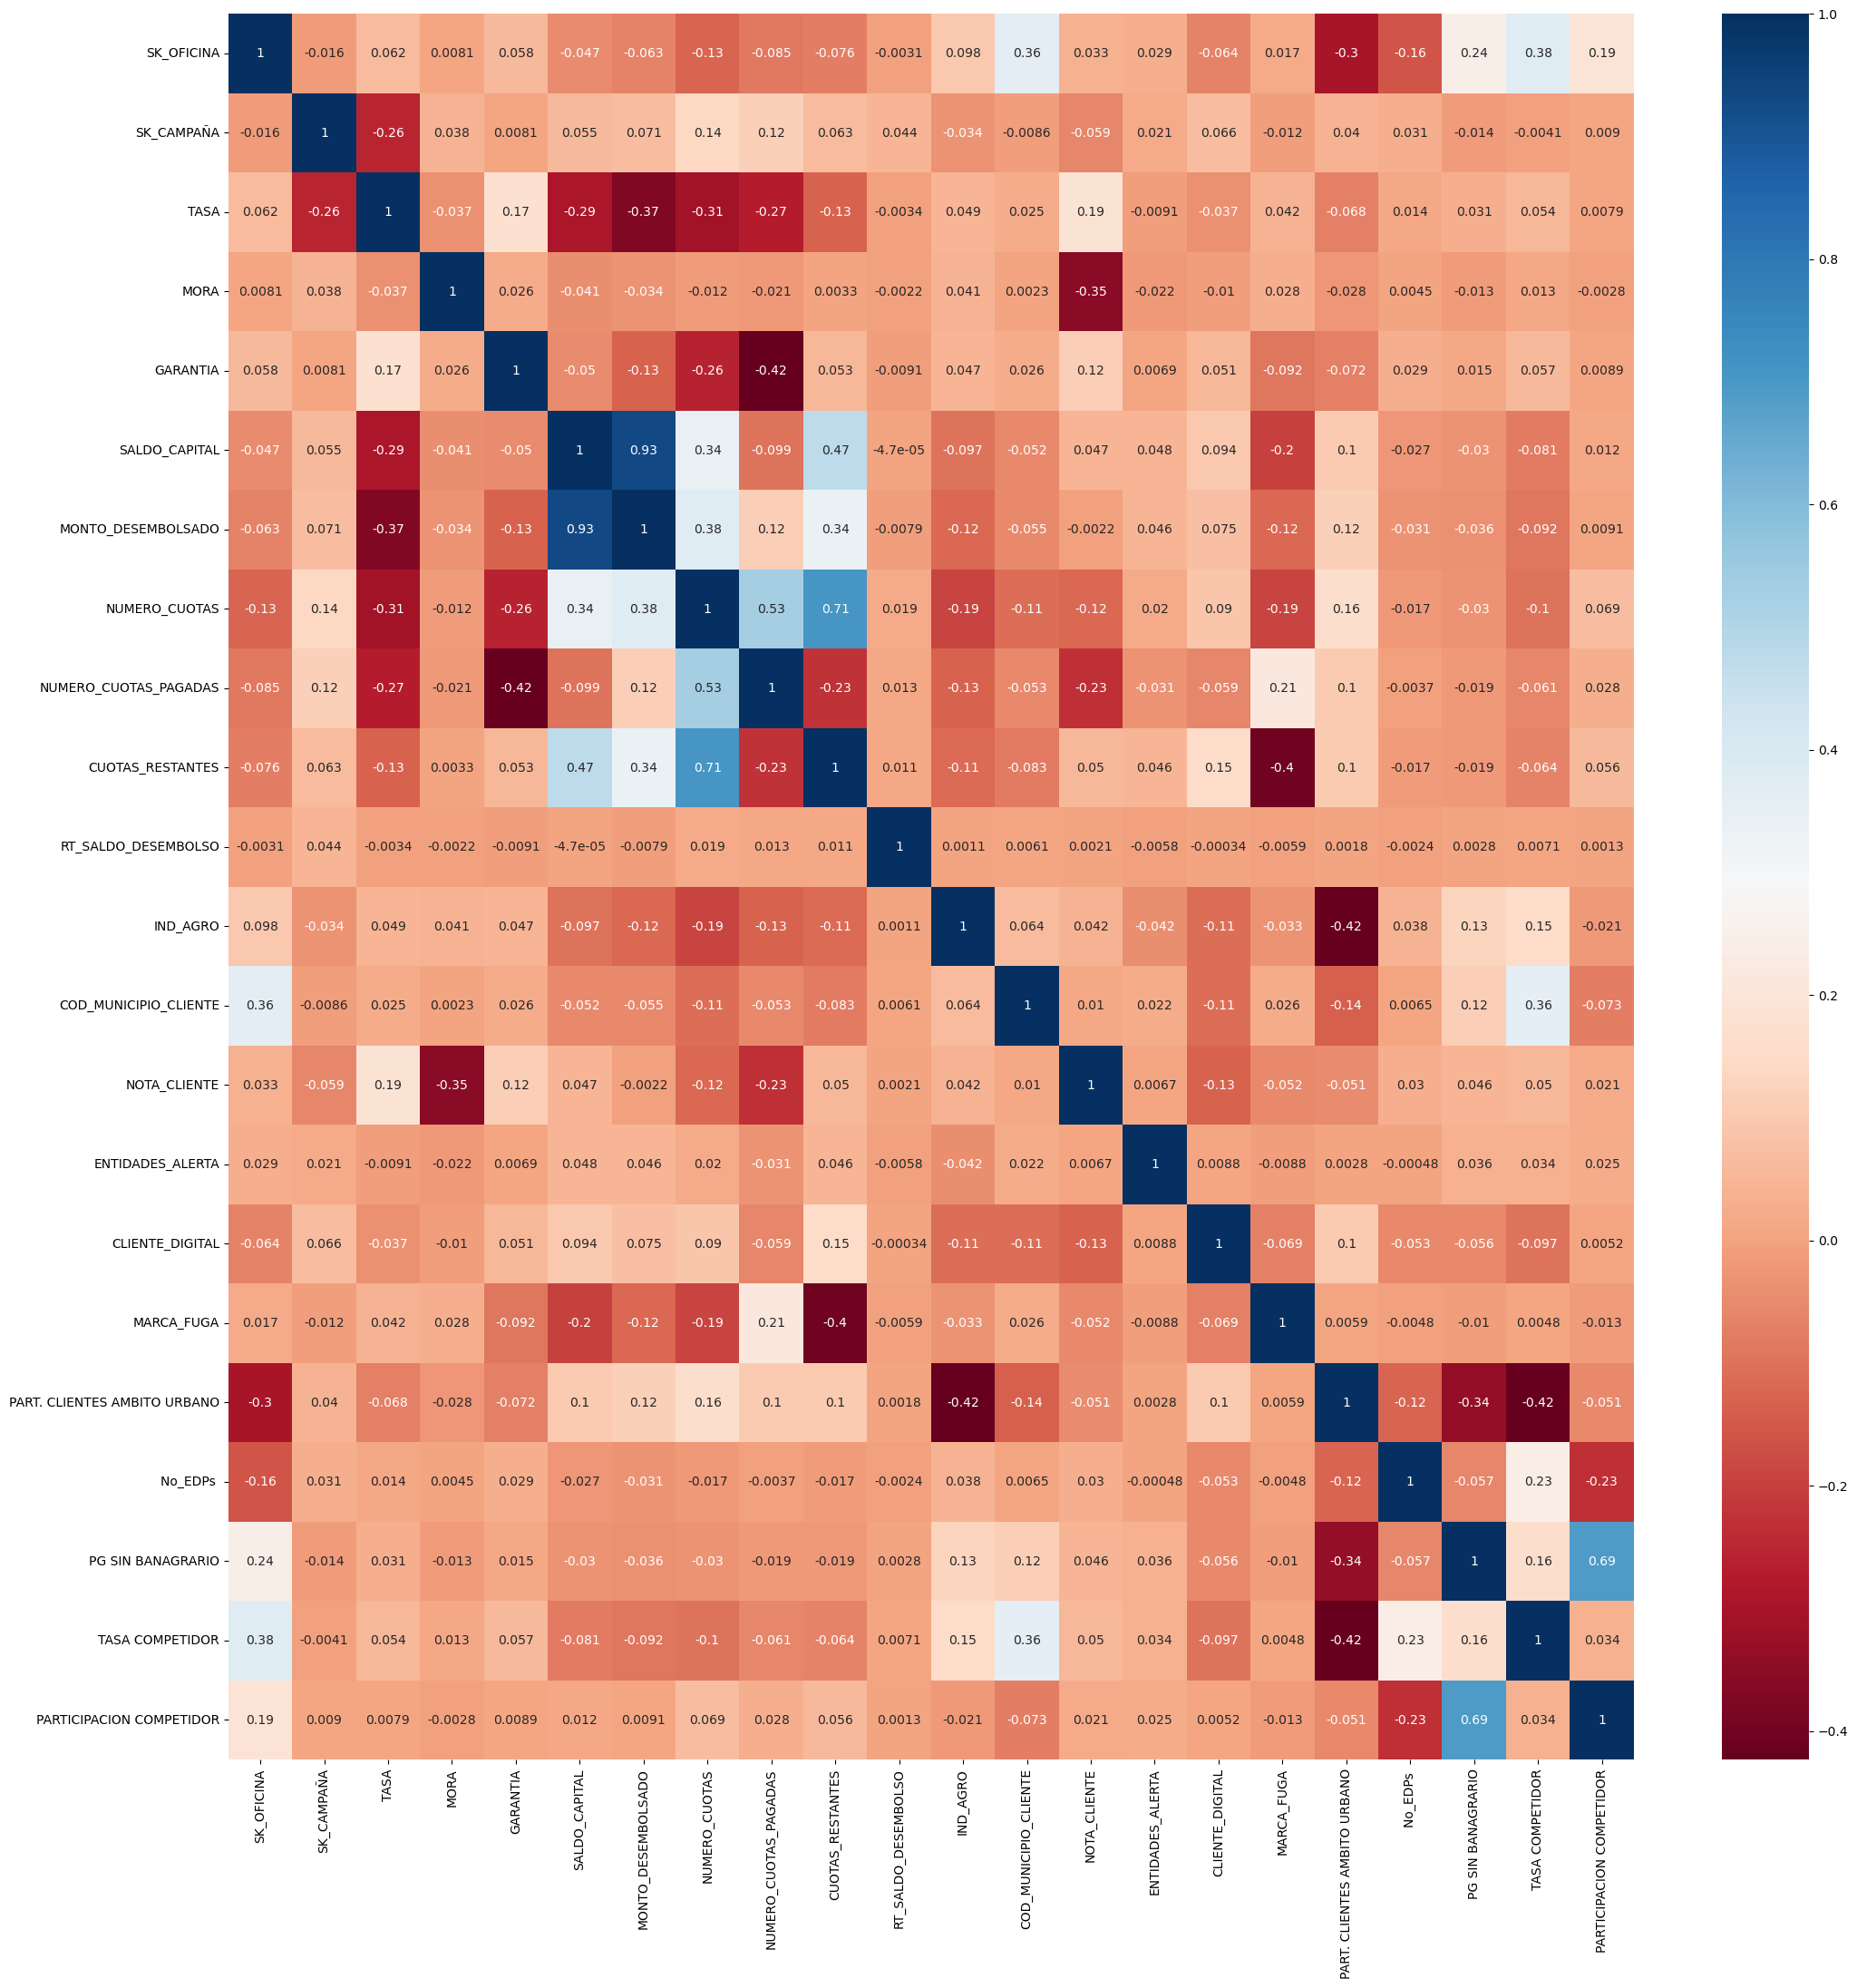

In [88]:
plt.figure(figsize=(25,25))
sns.heatmap(df2.select_dtypes(include=['int64', 'float64']).corr(), annot=True, cmap='RdBu')
plt.show()

##<p><strong>Paso: Preparar lo datos</strong></br>

In [89]:
df2['PORC_CUOTAS_PAGADAS'] = df2['NUMERO_CUOTAS_PAGADAS'] / df2['NUMERO_CUOTAS']
# df2['SALDO_RELATIVO'] = df2['SALDO_CAPITAL'] / df2['MONTO_DESEMBOLSADO']

# si 'PORC_CUOTAS_PAGADAS'] > 0.99 entonces lo deja como maximo 0.99
# df2['PORC_CUOTAS_PAGADAS'] = df2['PORC_CUOTAS_PAGADAS'].clip(upper=0.99)
# 0/0 Nulos a 0
df2['PORC_CUOTAS_PAGADAS'] = df2['PORC_CUOTAS_PAGADAS'].replace([np.inf, -np.inf], np.nan).fillna(0)

In [90]:
df2['PORC_CUOTAS_PAGADAS'].describe()

count    126369.000000
mean          0.429961
std           0.282238
min           0.000000
25%           0.194444
50%           0.416667
75%           0.666667
max           1.500000
Name: PORC_CUOTAS_PAGADAS, dtype: float64

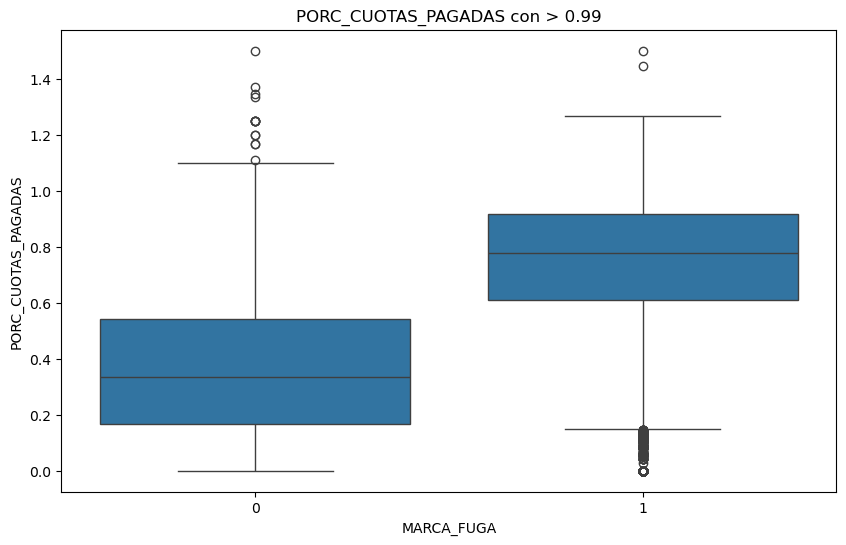

In [91]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df2, x='MARCA_FUGA', y='PORC_CUOTAS_PAGADAS')
# --- AQUÍ ESTÁ EL TRUCO ---
plt.ticklabel_format(style='plain', axis='y') 
plt.title('PORC_CUOTAS_PAGADAS con > 0.99')
# Si el saldo está en el eje X, cambia axis='y' por axis='x'
plt.show()

In [93]:
# plt.figure(figsize=(10, 6))
# sns.boxplot(data=df2, x='MARCA_FUGA', y='PORC_CUOTAS_PAGADAS')
# # --- AQUÍ ESTÁ EL TRUCO ---
# plt.ticklabel_format(style='plain', axis='y') 
# plt.title('PORC_CUOTAS_PAGADAS sin > 0.99')
# # Si el saldo está en el eje X, cambia axis='y' por axis='x'
# plt.show()

In [28]:
# df2['PORC_CUOTAS_PAGADAS'].head()

0    0.229167
1    0.444444
2    0.000000
3    0.111111
4    0.333333
Name: PORC_CUOTAS_PAGADAS, dtype: float64

In [34]:
# niv=[['bajo','medio','alto']]
# encoder0 = OrdinalEncoder(categories=niv)
# df2['RIESGO'] = encoder0.fit_transform(df2[['RIESGO']])

In [94]:
# Lista de niveles en el orden de:  (menor a mayor riesgo)
niveles = [['A', 'B', 'C', 'D', 'E']]
encoder = OrdinalEncoder(categories=niveles)
# Aplicamos al DataFrame (necesita doble corchete [[]])
df2['CALIFICACION'] = encoder.fit_transform(df2[['CALIFICACION']])

#
niveles2 = [['1. PERFIL_BUEN_CLIENTE', '2. PERFIL_MEDIO_CLIENTE', '3. PERFIL_MAL_CLIENTE']]
encoder2 = OrdinalEncoder(categories=niveles2)
df2['MARCA_CLIENTE'] = encoder2.fit_transform(df2[['MARCA_CLIENTE']])

In [95]:
# Definir
cortes = [0, 1000000, 50000000, 100000000, 156000000]
nombres = [0, 1, 2, 3] # rangos en numeros

df2['SALDO_CAPITAL_RANGO'] = pd.cut(df2['SALDO_CAPITAL'], 
                                    bins=cortes, 
                                    labels=nombres, 
                                    include_lowest=True)

#  convertir a float/int por pd.cut devuelve tipo 'category'
df2['SALDO_CAPITAL_RANGO'] = df2['SALDO_CAPITAL_RANGO'].astype(float)

In [124]:

# Definimos los cortess
cortes = [-float('inf'), 0, 30, 60, 90, 180, 360, float('inf')]
nombres = [0, 1, 2, 3, 4, 5, 6] # Etiquetas numéricas para el modelo

df2['TRAMO_MORA'] = pd.cut(df2['MORA'], bins=cortes, labels=nombres)
df2['TRAMO_MORA'] = df2['TRAMO_MORA'].astype(int)

In [126]:
df2['TRAMO_MORA'].describe()

count    126369.000000
mean          0.245305
std           0.717686
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           6.000000
Name: TRAMO_MORA, dtype: float64

In [96]:
# Defir
binss = [-float('inf'), 0, 0.99, float('inf')]
labelss = [0, 1, 2] # 0: Nada, 1: En proceso (0.01-0.99), 2: Completado (1.0+)

df2['GRUPO_PAGO'] = pd.cut(df2['PORC_CUOTAS_PAGADAS'], bins=binss, labels=labelss)

# Convertir a entero
df2['GRUPO_PAGO'] = df2['GRUPO_PAGO'].astype(int)

In [98]:
df2['GRUPO_PAGO'].describe()

count    126369.000000
mean          0.943333
std           0.321371
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           2.000000
Name: GRUPO_PAGO, dtype: float64

In [32]:
# cate = [['MASCULINO', 'FEMENINO']]
# encoder2 = OrdinalEncoder(categories=cate)
# df2['GENERO'] = encoder2.fit_transform(df2[['GENERO']])

In [99]:
print(df2[['MARCA_CLIENTE']].head())

   MARCA_CLIENTE
0            0.0
1            0.0
2            0.0
3            0.0
4            2.0


In [100]:
print(df2[df2['MARCA_CLIENTE'] == 1.0].head())

    SK_OFICINA  SK_CAMPAÑA   TASA  MORA  CALIFICACION  GARANTIA  \
24         221           0  44.46     0           0.0         1   
35         604           0  50.23     0           1.0         1   
44         288           0  48.54     0           0.0         1   
48         214           0  50.80    21           0.0         0   
58         257           0  50.33    28           0.0         0   

    SALDO_CAPITAL  MONTO_DESEMBOLSADO  NUMERO_CUOTAS  NUMERO_CUOTAS_PAGADAS  \
24     5279298.25           5296800.0             36                      2   
35     1592846.69           2550400.0             18                      9   
44     5941125.81           5999000.0             36                      3   
48     1954712.18           4115200.0             36                     24   
58     6100276.52          10239040.0             24                     12   

    ...  MARCA_FUGA  PART. CLIENTES AMBITO URBANO No_EDPs   PG SIN BANAGRARIO  \
24  ...           0                      

In [81]:
# print(df2['CALIFICACION'].sort_values())

126357    0.0
126358    0.0
126359    0.0
126360    0.0
126363    0.0
         ... 
13        4.0
47        4.0
126364    4.0
126361    4.0
86        4.0
Name: CALIFICACION, Length: 126369, dtype: float64


In [60]:
# df.head(50)

In [145]:
#Dividiremos el conjunto de datos en característicias (features) y la variable objetivo (target)

# 'X' contiene todas las columnas numéricas EXCEPTO la que quieres predecir
X = df2.drop(columns=['MARCA_FUGA','CLIENTE_DIGITAL','SK_OFICINA','SK_CAMPAÑA','NUMERO_CUOTAS','CUOTAS_RESTANTES','CLIENTE_DIGITAL','GENERO',
                      'NUMERO_CUOTAS_PAGADAS','ENTIDADES_ALERTA','MONTO_DESEMBOLSADO','GARANTIA','NOTA_CLIENTE','COD_MUNICIPIO_CLIENTE','No_EDPs ',
                      'PG SIN BANAGRARIO','PART. CLIENTES AMBITO URBANO','PARTICIPACION COMPETIDOR','MARCA_CLIENTE','RIESGO','SALDO_CAPITAL',
                      'PORC_CUOTAS_PAGADAS','MORA','IND_AGRO'])

# 'y' contiene solo la columna que quieres predecir
y = df2['MARCA_FUGA']

In [146]:
X.dtypes

TASA                   float64
CALIFICACION           float64
RT_SALDO_DESEMBOLSO    float64
TASA COMPETIDOR        float64
SALDO_CAPITAL_RANGO    float64
GRUPO_PAGO               int64
TRAMO_MORA               int64
dtype: object

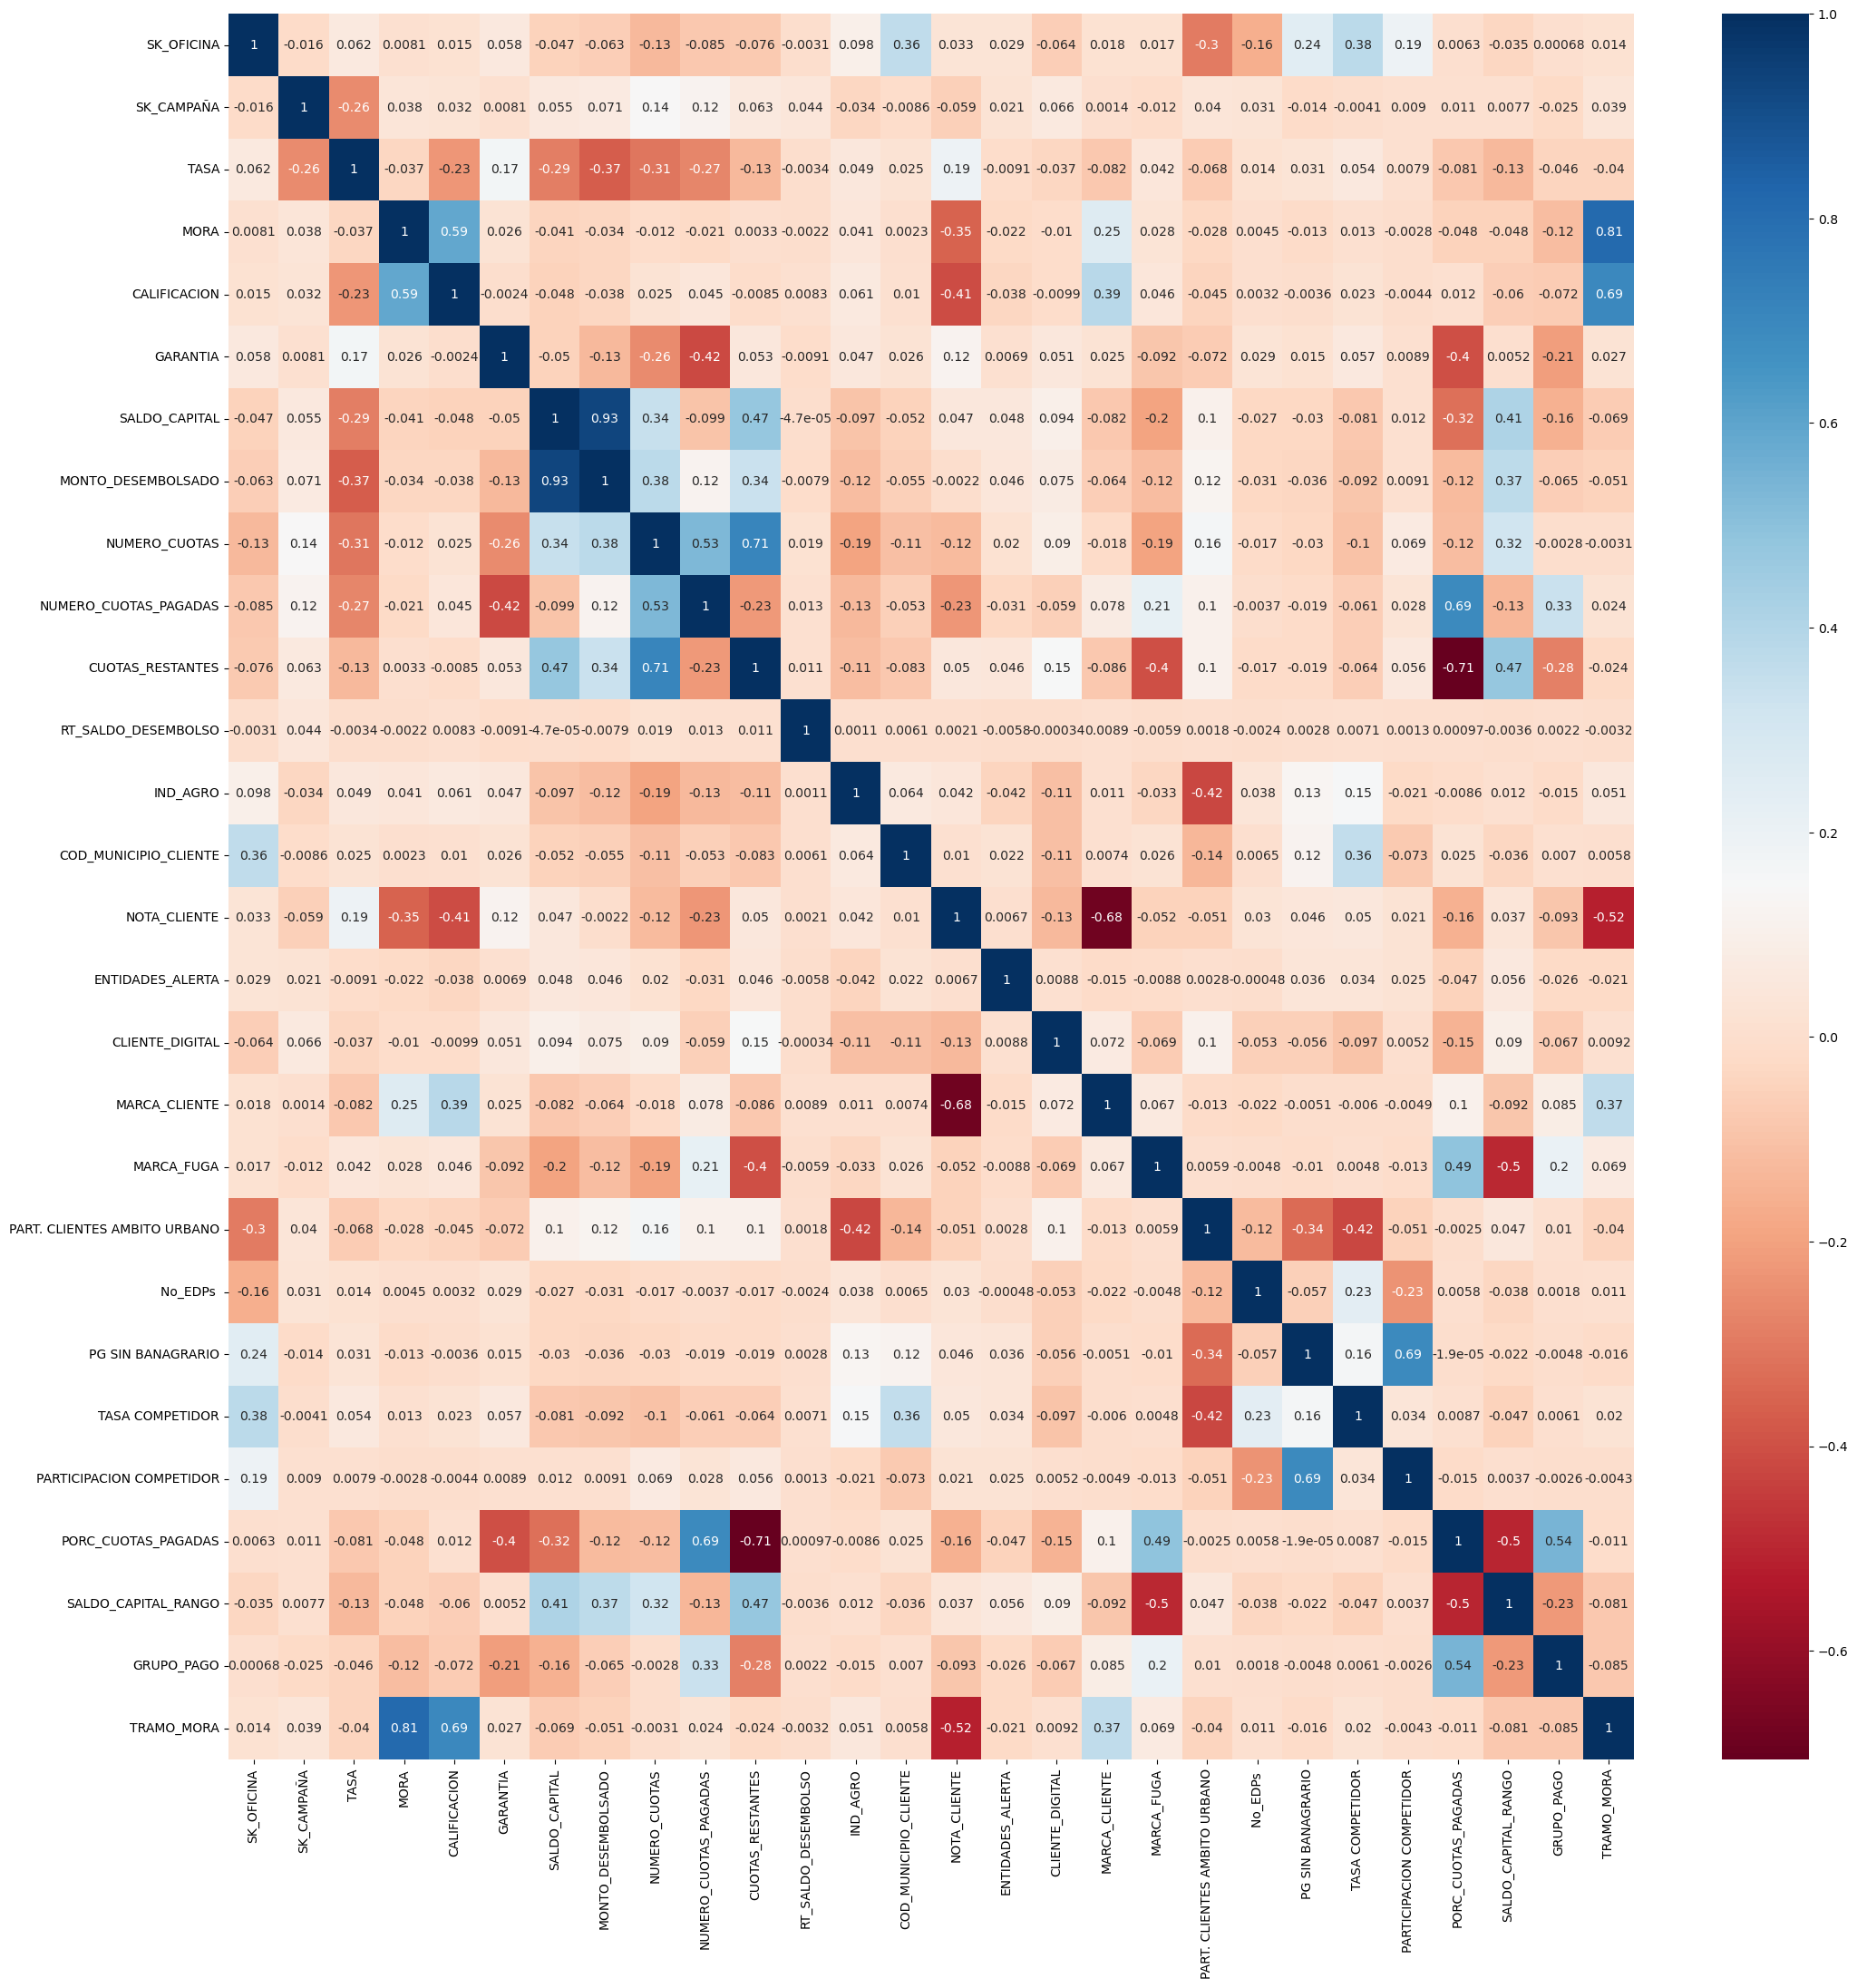

In [147]:
plt.figure(figsize=(25,25))
sns.heatmap(df2.select_dtypes(include=['int64', 'float64']).corr(), annot=True, cmap='RdBu')
plt.show()

## datos en entrenamiento y pruebas

##<p><strong>Paso: División del conjunto de datos en entrenamiento y pruebas </strong></br>
Para poder identificar la mejor parametrización de los algoritmos se usan diferentes estrategias. Una de ellas se llama Hold-Out y consiste en dejar un porcentaje para entrenar y otra para probar. Normalmente 60% para entrenar y 40% para probar.

In [148]:
# Dividir el conjunto de datos conjunto de entrenamiento y en conjunto de pruebas
# 70% entrenamiento y 30% prueba
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
 # 60% entrenamiento y 40% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=1)

##<p><strong>Paso: Entrenamiento y prueba del Arbol de Decision</strong></br>
 entrenamiento (X_train y Y_train) y luego haremos la predicción al conjunto de prueba (X_test)

# Entrenar el árbol de decisión
model = model.fit(X_train,y_train)

#Predecir la variable objetivo en los datos de prueba (probar el modelo)
y_pred = model.predict(X_test)

In [131]:
# Accuracy, permite identificar qué tan confiable es el modelo. Qué tantas predicciones correctas realizó? Se compara el valor original en y_test con el valor predicho en y_pred
print("Matriz de confusión: \n", confusion_matrix(y_test, y_pred))

print("Matriz de confusión normalizada: \n", confusion_matrix(y_test, y_pred, normalize="true"))
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print("TN,FP,FN,TP \n", (tn, fp, fn, tp))

Matriz de confusión: 
 [[36367  4792]
 [ 2140  7249]]
Matriz de confusión normalizada: 
 [[0.88357346 0.11642654]
 [0.2279263  0.7720737 ]]
TN,FP,FN,TP 
 (np.int64(36367), np.int64(4792), np.int64(2140), np.int64(7249))


In [106]:
# Ahora calcularemos las métricas derivadas de la matriz de confusión
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.89      0.92     41159
           1       0.62      0.76      0.68      9389

    accuracy                           0.87     50548
   macro avg       0.78      0.83      0.80     50548
weighted avg       0.88      0.87      0.87     50548



##<p><strong>Paso: Visualización </strong></br>
 Visualizaremos el árbol de decisión

In [198]:
#Primero visualizaremos el número de nodos
n_nodes = model.tree_.node_count
print("El árbol construido tiene ", n_nodes, "nodos ")
#Ahora visualizaremos el árbol en modo texto
arbol = tree.export_text(model, feature_names=X.columns.tolist(), show_weights=True)
print(arbol)

El árbol construido tiene  193 nodos 
|--- PORC_CUOTAS_PAGADAS <= 0.66
|   |--- SALDO_CAPITAL <= 1233417.38
|   |   |--- PORC_CUOTAS_PAGADAS <= 0.56
|   |   |   |--- MORA <= 18.50
|   |   |   |   |--- PORC_CUOTAS_PAGADAS <= 0.44
|   |   |   |   |   |--- TASA <= 52.50
|   |   |   |   |   |   |--- SALDO_CAPITAL <= 744890.00
|   |   |   |   |   |   |   |--- weights: [55.16, 40.72] class: 0
|   |   |   |   |   |   |--- SALDO_CAPITAL >  744890.00
|   |   |   |   |   |   |   |--- weights: [858.04, 198.17] class: 0
|   |   |   |   |   |--- TASA >  52.50
|   |   |   |   |   |   |--- PORC_CUOTAS_PAGADAS <= 0.26
|   |   |   |   |   |   |   |--- weights: [188.77, 73.30] class: 0
|   |   |   |   |   |   |--- PORC_CUOTAS_PAGADAS >  0.26
|   |   |   |   |   |   |   |--- weights: [9.19, 38.01] class: 1
|   |   |   |   |--- PORC_CUOTAS_PAGADAS >  0.44
|   |   |   |   |   |--- TASA <= 56.69
|   |   |   |   |   |   |--- weights: [307.67, 230.75] class: 0
|   |   |   |   |   |--- TASA >  56.69
|   |   | 

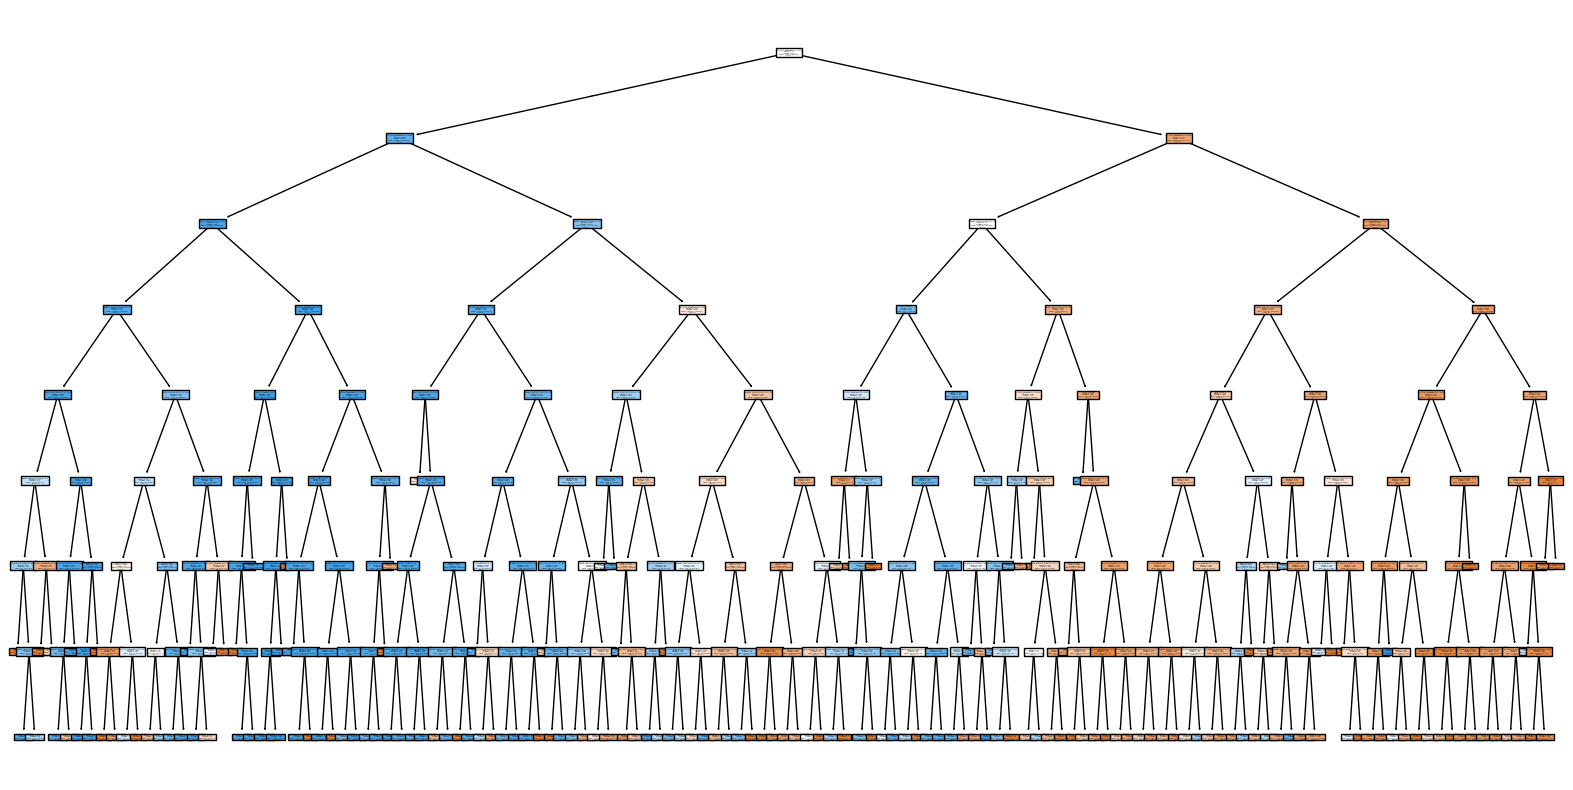

In [214]:
#Ahora visualizaremos el árbol gráficamente
plt.figure(figsize=(20,10))
tree.plot_tree(model,
               feature_names=X.columns.tolist(),
               class_names=['0','1'],
               filled=True)
plt.show()

##<p><strong>Paso: Probando otros parámetros para crear el árbol</strong></br>
</a>

In [149]:
# Crear el objeto árbol de decisión
model2 = DecisionTreeClassifier(random_state=5, criterion="entropy", class_weight="balanced")

# Entrenar el árbol
model2 = model2.fit(X_train,y_train)

# Predecir los valores del conjunto de prueba
y_pred = model2.predict(X_test)

In [150]:
#Calcularemos nuevamente las medidas de desempeño
# Accuracy, permite identificar qué tan confiable es el modelo. Qué tantas predicciones correctas realizó? Se compara el valor original en y_test con el valor predicho en y_pred
print("Matriz de confusión: \n", confusion_matrix(y_test, y_pred))
print("Matriz de confusión normalizada: \n", confusion_matrix(y_test, y_pred, normalize="true"))
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print("TN,FP,FN,TP \n", (tn, fp, fn, tp))

# Ahora calcularemos las métricas derivadas de la matriz de confusión
print(classification_report(y_test, y_pred))

Matriz de confusión: 
 [[36881  4278]
 [ 4309  5080]]
Matriz de confusión normalizada: 
 [[0.89606161 0.10393839]
 [0.45894131 0.54105869]]
TN,FP,FN,TP 
 (np.int64(36881), np.int64(4278), np.int64(4309), np.int64(5080))
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     41159
           1       0.54      0.54      0.54      9389

    accuracy                           0.83     50548
   macro avg       0.72      0.72      0.72     50548
weighted avg       0.83      0.83      0.83     50548



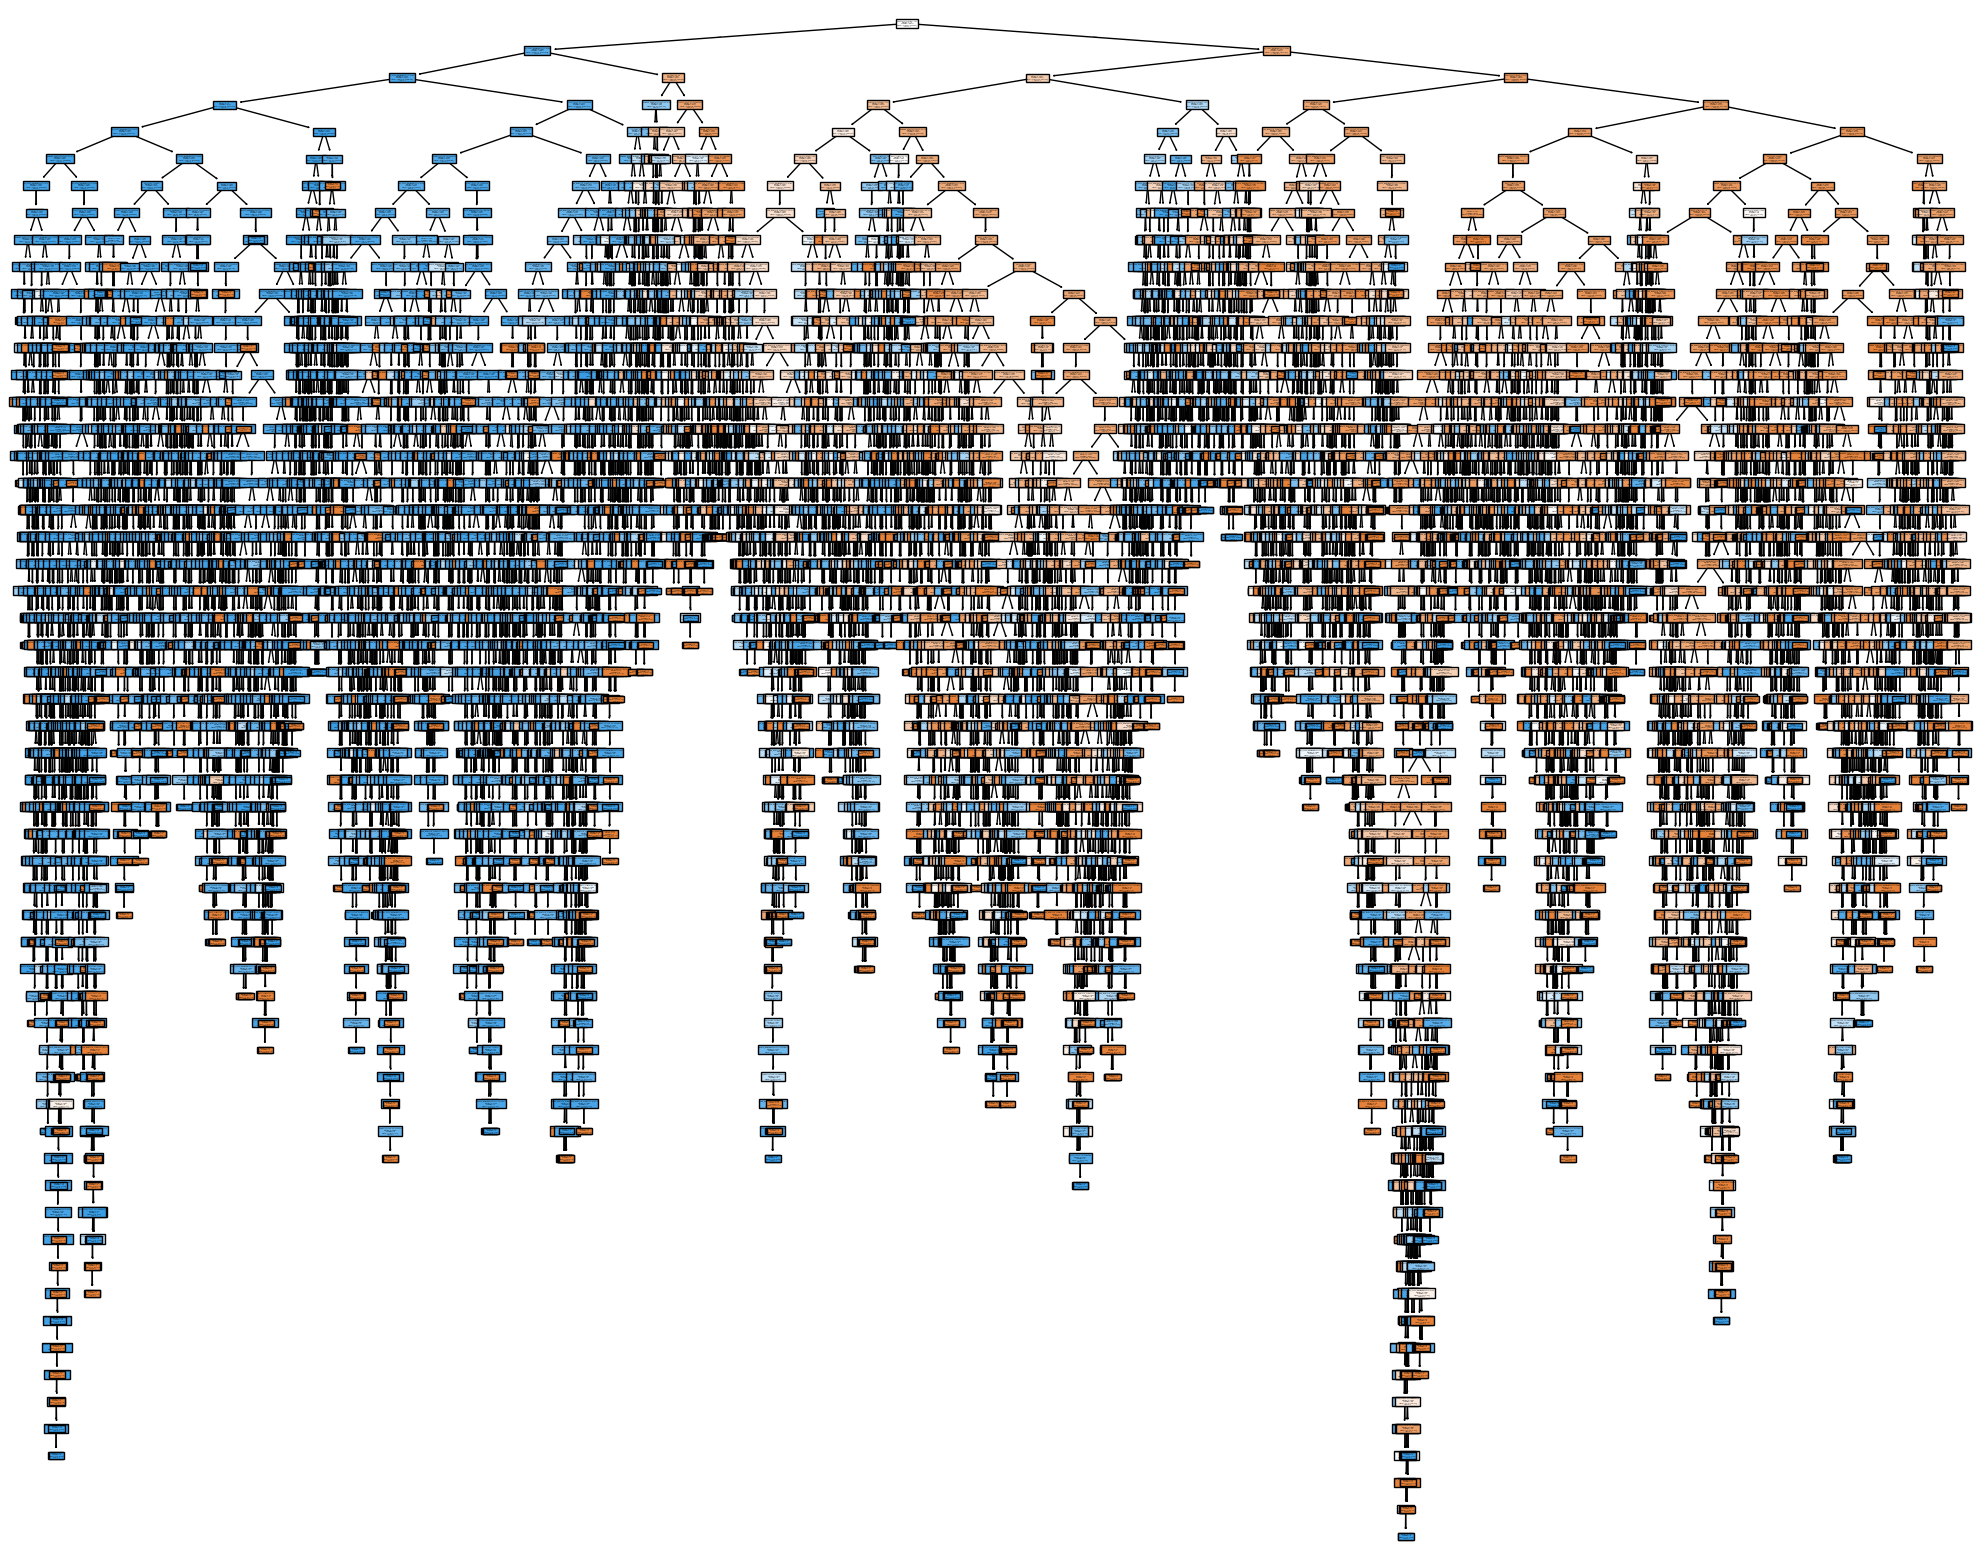

In [113]:
#Ahora visualizaremos el árbol gráficamente
plt.figure(figsize=(25,20))
tree.plot_tree(model2,
               feature_names=X.columns.tolist(),
               class_names=['0','1'],
               filled=True)
plt.show()

# pre-poda

##<p><strong>Paso: Podar para evitar sobreajuste o sobre alimentación </strong></br>


In [151]:
# Crear el objeto árbol de decisión
model = DecisionTreeClassifier(random_state=5, criterion="entropy", class_weight="balanced", min_samples_leaf=20, max_depth=7)

# Entrenar el árbol
model = model.fit(X_train,y_train)

# Predecir los valores del conjunto de prueba
y_pred = model.predict(X_test)

#Evaluemos el desempeño del nuevo árbol
print("Accuracy: \n", metrics.accuracy_score(y_test, y_pred))

Accuracy: 
 0.8620914774076126


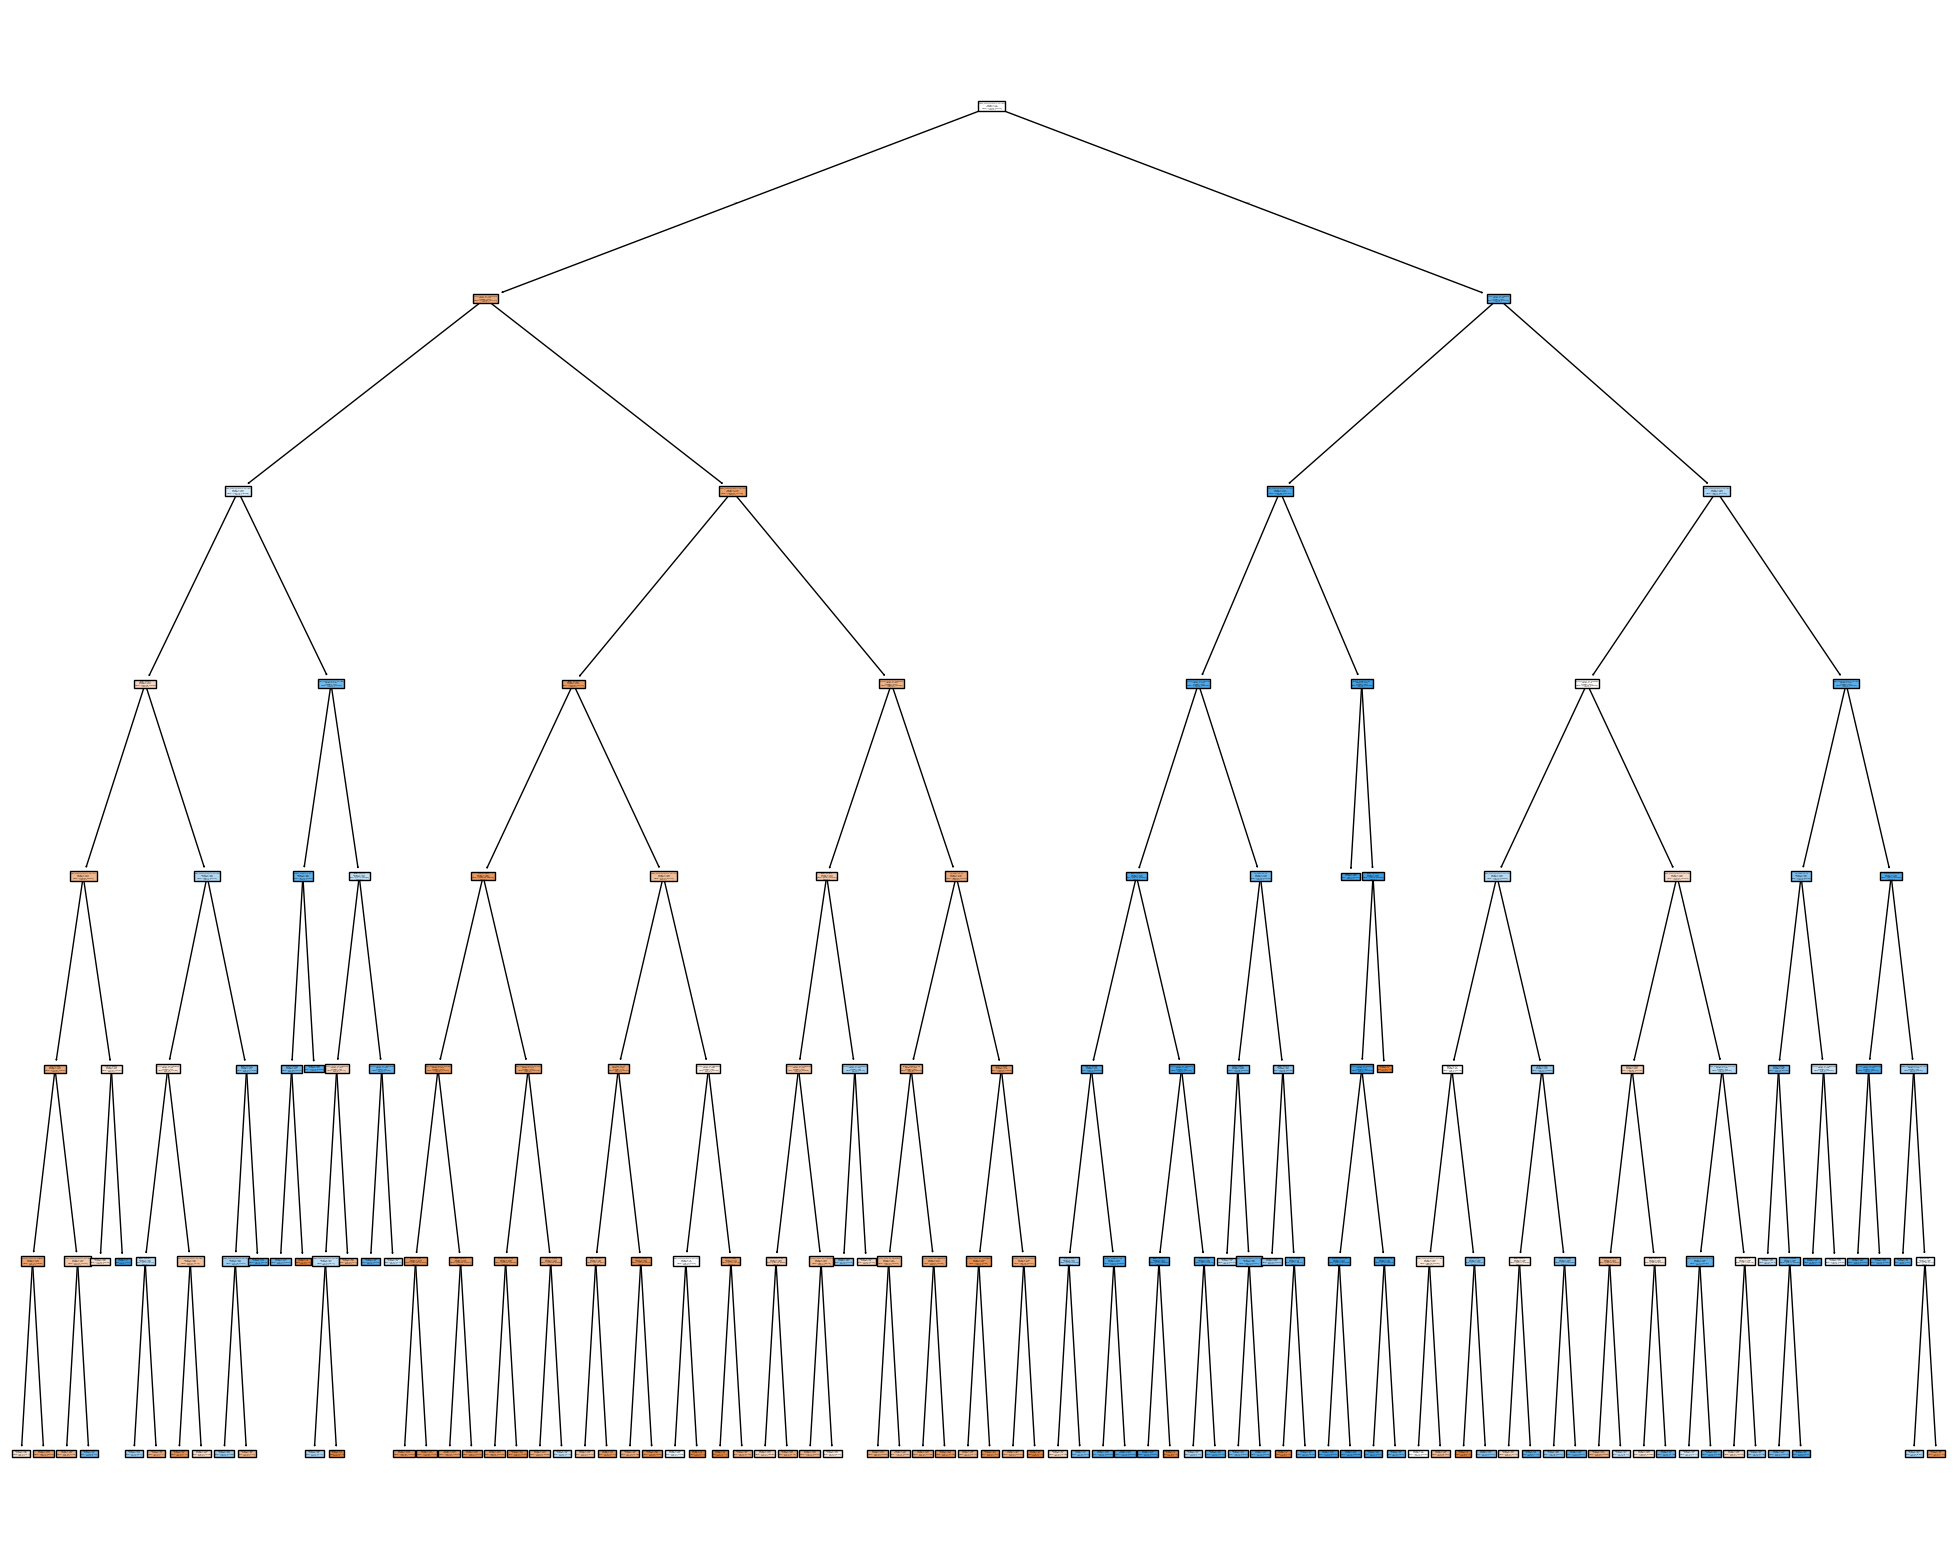

In [197]:
#Ahora visualizaremos el árbol gráficamente
plt.figure(figsize=(25,20))
tree.plot_tree(model,
               feature_names=X.columns.tolist(),
               class_names=['0','1'],
               filled=True)
plt.show()

In [196]:
#Para poder ver mejor los nodos lo visualizaremos en modo texto
arbol = tree.export_text(model, feature_names=X.columns.tolist(), show_weights=True)
print(arbol)

|--- PORC_CUOTAS_PAGADAS <= 0.66
|   |--- SALDO_CAPITAL <= 1233417.38
|   |   |--- PORC_CUOTAS_PAGADAS <= 0.56
|   |   |   |--- MORA <= 18.50
|   |   |   |   |--- PORC_CUOTAS_PAGADAS <= 0.44
|   |   |   |   |   |--- TASA <= 52.50
|   |   |   |   |   |   |--- SALDO_CAPITAL <= 744890.00
|   |   |   |   |   |   |   |--- weights: [55.16, 40.72] class: 0
|   |   |   |   |   |   |--- SALDO_CAPITAL >  744890.00
|   |   |   |   |   |   |   |--- weights: [858.04, 198.17] class: 0
|   |   |   |   |   |--- TASA >  52.50
|   |   |   |   |   |   |--- PORC_CUOTAS_PAGADAS <= 0.26
|   |   |   |   |   |   |   |--- weights: [188.77, 73.30] class: 0
|   |   |   |   |   |   |--- PORC_CUOTAS_PAGADAS >  0.26
|   |   |   |   |   |   |   |--- weights: [9.19, 38.01] class: 1
|   |   |   |   |--- PORC_CUOTAS_PAGADAS >  0.44
|   |   |   |   |   |--- TASA <= 56.69
|   |   |   |   |   |   |--- weights: [307.67, 230.75] class: 0
|   |   |   |   |   |--- TASA >  56.69
|   |   |   |   |   |   |--- weights: [0.00, 13.

##<p><strong>Paso: Optimizando los hiperparámetros del modelo</strong><br>
Probar cuáles son los mejores parámetros para el modelo es muy dispendioso. Afortunadamene hay librerías que nos ayudan en esta labor.

In [152]:
#Función para optimizar los parámetros de un árbol de decisión
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

def dtree_grid_search(X,y,nfolds,n_jobs=-1):
    #crear un diccionario con todos los valores que se quieren probar
    param_grid = { 'criterion':['gini','entropy'],'max_depth': np.arange(3, 15), 'min_samples_split': np.arange(20, 30)  }
    # Crear el objeto árbol de decisión
    dtree_model=DecisionTreeClassifier()
    #use gridsearch para probar todos los valores
    dtree_gscv = GridSearchCV(dtree_model, param_grid, cv=nfolds)
    #entrenaremos
    dtree_gscv.fit(X, y)
    return dtree_gscv.best_params_

In [153]:
#Acá llamaremos la función para calcular los mejores parámetros
bestparam = dtree_grid_search(X_train,y_train,4)
print ("Los mejores parámetros son", bestparam)

Los mejores parámetros son {'criterion': 'entropy', 'max_depth': np.int64(7), 'min_samples_split': np.int64(28)}


In [154]:
# Crear el árbol de decisión con los mejores parámetros el ** es para desempaquetar el objeto dict (diccionario).
model = DecisionTreeClassifier(**bestparam, random_state=5, class_weight="balanced")

# Entrenar el árbol
model = model.fit(X_train,y_train)

#Predecir los valores del conjunto de entrenamiento
y_pred = model.predict(X_test)

# Calcular el accuracy
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.8620716942312258


#  Pos-Poda con ccp_alpha

In [155]:
# El parámetro de complejidad de costos, ccp_alpha permite podar el árbol. Mayores valores de ccp_alpha aumentan el número de nodos podados
# Para identificar el valor más apropiado, graficaremos el accuracy en prueba y en entrenamiento, para ver en cuál valor de complejidad se alcanza el mejor accuracy en pruebas
path = model.cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas
accuracy_train, accuracy_test=[],[]
max_testAccuracy = 0
for i in alphas:
  model=DecisionTreeClassifier(ccp_alpha=i)
  model = model.fit(X_train,y_train)
  y_train_pred=model.predict(X_train)
  y_test_pred=model.predict(X_test)
  accuracy_train.append(metrics.accuracy_score(y_train, y_train_pred))
  accuracy_test.append(metrics.accuracy_score(y_test, y_test_pred))
  #Identificaremos cuál es el valor del alpha que más aumenta el accuracy en el set de pruebas
  if (max_testAccuracy < metrics.accuracy_score(y_test, y_test_pred)):
    max_testAccuracy = metrics.accuracy_score(y_test, y_test_pred)
    selectedlAlpha = i
selectedlAlpha

np.float64(4.3001144363073555e-05)

In [156]:
# Crearemos el último árbol con los mejores parámetros detectados y el valor de alpha detectado como el mejor para aumentar el accuracy
model = DecisionTreeClassifier(**bestparam, random_state = 6, class_weight = "balanced", ccp_alpha = selectedlAlpha)
model = model.fit(X_train,y_train)
y_train_pred=model.predict(X_train)
y_test_pred=model.predict(X_test)
print("El accuracy de entrenamiento es: ", metrics.accuracy_score(y_train, y_train_pred), "y el de pruebas es: ", metrics.accuracy_score(y_test, y_test_pred))

# Ahora calcularemos las métricas derivadas de la matriz de confusión

# print(classification_report(y_test, y_pred))


#Obtener las probabilidades de la clase 1 (Fuga)
# predict_proba devuelve [prob_clase_0, prob_clase_1]
y_probs = model.predict_proba(X_test)[:, 1]

# nuevo umbral ...
y_test_pred_70 = (y_probs >= 0.7).astype(int)
# y_test_pred_70 = (y_probs >= 0.5863).astype(int)

# 3. Ver los resultados con el nuevo umbral
print("--- Reporte con Umbral 0.70 ---")
print(classification_report(y_test, y_test_pred_70))

El accuracy de entrenamiento es:  0.8659078619379855 y el de pruebas es:  0.8620914774076126
--- Reporte con Umbral 0.70 ---
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     41159
           1       0.69      0.68      0.69      9389

    accuracy                           0.88     50548
   macro avg       0.81      0.81      0.81     50548
weighted avg       0.88      0.88      0.88     50548



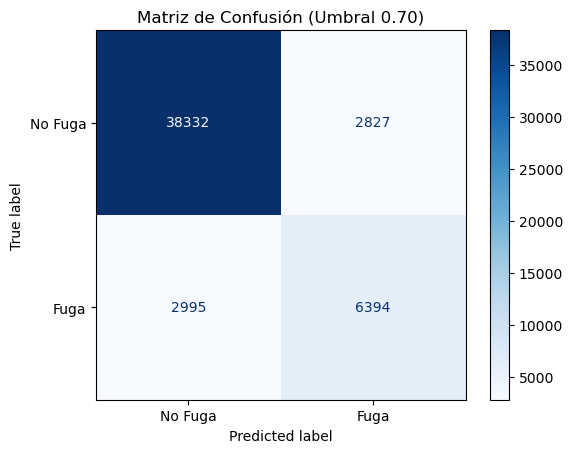

Falsas alarmas (Clientes que NO se iban): 2827
Fugas no detectadas (Clientes que SE FUERON y no vimos): 2995
Fugas detectadas con éxito: 6394


In [157]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Usamos las predicciones del umbral 0.70
cm = confusion_matrix(y_test, y_test_pred_70)

# Visualización
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Fuga', 'Fuga'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión (Umbral 0.70)')
plt.show()

# Para ver los números exactos en texto:
tn, fp, fn, tp = cm.ravel()
print(f"Falsas alarmas (Clientes que NO se iban): {fp}")
print(f"Fugas no detectadas (Clientes que SE FUERON y no vimos): {fn}")
print(f"Fugas detectadas con éxito: {tp}")

In [94]:
# from sklearn.metrics import precision_recall_curve, roc_curve, auc
# import matplotlib.pyplot as plt

# 1. Calcular los valores para ambas curvas
# Usamos y_probs (las probabilidades que ya calculaste)
# fpr, tpr, _ = roc_curve(y_test, y_probs)
# roc_auc = auc(fpr, tpr)

# precision, recall, _ = precision_recall_curve(y_test, y_probs)
# pr_auc = auc(recall, precision)

# # 2. Graficar
# fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# # Gráfico ROC
# ax[0].plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
# ax[0].plot([0, 1], [0, 1], color='navy', linestyle='--')
# ax[0].set_title('Curva ROC')
# ax[0].set_xlabel('Tasa de Falsos Positivos')
# ax[0].set_ylabel('Tasa de Verdaderos Positivos (Recall)')
# ax[0].legend()

# # Gráfico Precision-Recall
# ax[1].plot(recall, precision, color='green', label=f'PR curve (area = {pr_auc:.2f})')
# ax[1].set_title('Curva Precision-Recall')
# ax[1].set_xlabel('Recall')
# ax[1].set_ylabel('Precision')
# ax[1].legend()

# plt.show()

In [158]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score

# Definir los umbrales que queremos probar
umbrales = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]

resultados = []

for u in umbrales:
    # Aplicar el umbral a las probabilidades
    preds = (y_probs >= u).astype(int)
    
    # Calcular métricas para la clase 1 (Fuga)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = 2 * (prec * rec) / (prec + rec)
    
    resultados.append({
        'Umbral': u,
        'Precisión (Clase 1)': round(prec, 3),
        'Recall (Clase 1)': round(rec, 3),
        'F1-Score': round(f1, 3)
    })

# Mostrar la tabla comparativa
df_comparativo = pd.DataFrame(resultados)
print(df_comparativo)

   Umbral  Precisión (Clase 1)  Recall (Clase 1)  F1-Score
0    0.50                0.600             0.774     0.676
1    0.55                0.606             0.771     0.678
2    0.60                0.606             0.770     0.678
3    0.65                0.673             0.706     0.689
4    0.70                0.693             0.681     0.687
5    0.75                0.696             0.677     0.686
6    0.80                0.716             0.637     0.674
7    0.85                0.726             0.620     0.669
8    0.90                0.787             0.398     0.529


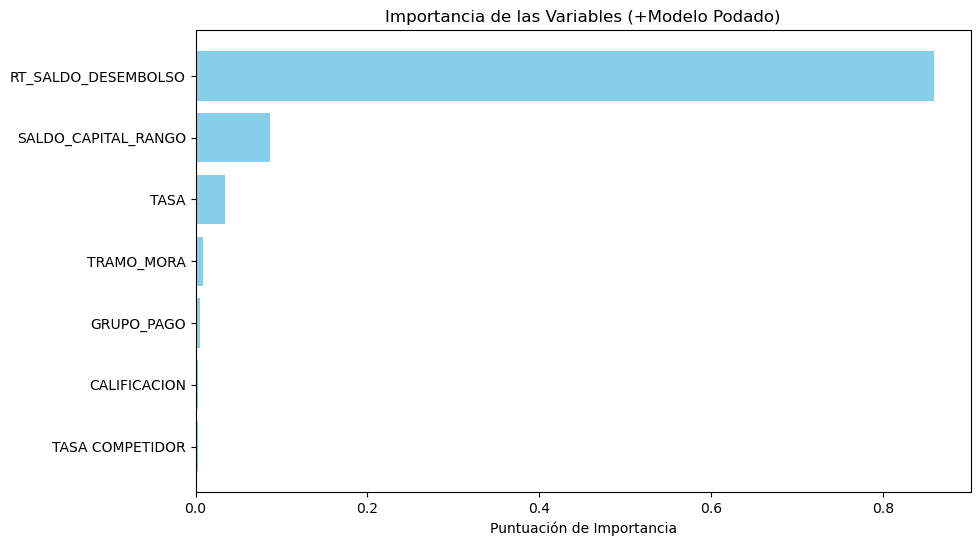

              Variable  Importancia
2  RT_SALDO_DESEMBOLSO     0.858884
4  SALDO_CAPITAL_RANGO     0.086531
0                 TASA     0.034748
6           TRAMO_MORA     0.009010
5           GRUPO_PAGO     0.005077
1         CALIFICACION     0.003157
3      TASA COMPETIDOR     0.002593


In [159]:
# Crear un DataFrame resultados
importancias = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': model.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# Visualizar
plt.figure(figsize=(10, 6))
plt.barh(importancias['Variable'], importancias['Importancia'], color='skyblue')
plt.gca().invert_yaxis() # Para que la más importante salga arriba
plt.title('Importancia de las Variables (+Modelo Podado)')
plt.xlabel('Puntuación de Importancia')
plt.show()

# Mostrar
print(importancias.head(50))

In [160]:
# df2.to_excel('datos_prj.xlsx', index=False)

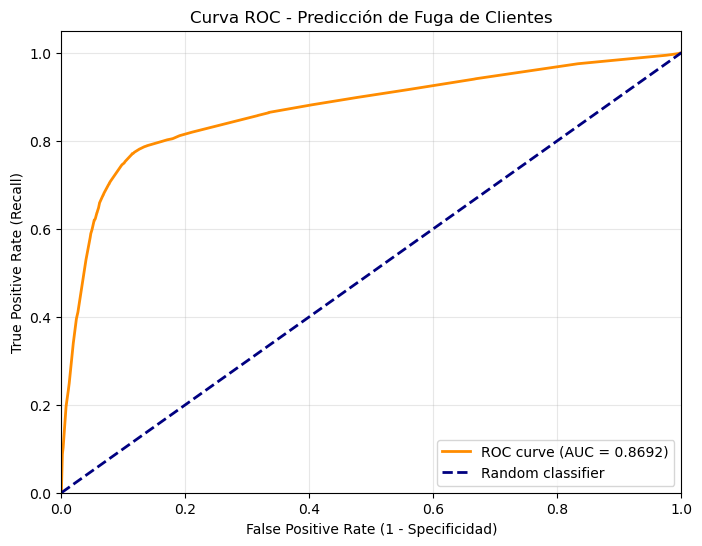

Umbral óptimo (Índice de Youden): 0.5962
TPR en umbral óptimo: 0.7705
FPR en umbral óptimo: 0.1142


In [161]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificidad)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Curva ROC - Predicción de Fuga de Clientes')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Umbral  óptimo por Youden
youden_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[youden_idx]
print(f"Umbral óptimo (Índice de Youden): {optimal_threshold:.4f}")
print(f"TPR en umbral óptimo: {tpr[youden_idx]:.4f}")
print(f"FPR en umbral óptimo: {fpr[youden_idx]:.4f}")

# 0.80-0.90 modelo dentro del rango ROC AUC

## MODELO Otro